# MORE vs LESS Access

Diverging bar charts showing which groups gain (`MORE`) or lose (`LESS`) access to resources, with the top 2 chi²-specific resources per side.

1. **All periods combined** — overall picture across the corpus.
2. **Per period** — one chart for each of the 5 historical periods.

In [1]:
import json, re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.dpi'] = 150

GEMINI_DIR = Path("../data/llm_results/gemini_v18")
sample = pd.read_csv("../data/perseus_works_wikidata_sample.tsv", sep="\t")

# Load all rules
all_rows = []
for fp in GEMINI_DIR.glob("tlg*.json"):
    with open(fp) as f: data = json.load(f)
    fid = data.get("_file_id", fp.stem)
    meta = sample[sample["file_id"] == fid]
    if len(meta) == 0: continue
    m = meta.iloc[0]
    for r in data.get("extracted_rules", []):
        if not isinstance(r, dict): continue
        all_rows.append({"author": m["perseus_author"], "group": str(r.get("group","")).strip(),
            "group_category": str(r.get("group_category","")).strip(),
            "resource_category": str(r.get("resource_category","")).strip(),
            "rule_category": str(r.get("rule_category","")).strip(),
            "direction": str(r.get("directionality","")).strip().upper(),
            "author_impact_date": m["author_impact_date"], "file_id": fid, "n_pages": m["n_pages"]})

df = pd.DataFrame(all_rows)

# Harmonize groups
def harmonize_who(v):
    s = str(v).strip().lower()
    if re.search(r"wom[ae]n|female|wife|maiden|widow|mother|daughter", s): return "Women"
    if re.search(r"slav|enslav|servil|bondage|unfree|helot", s): return "Slaves"
    if re.search(r"non.?citizen|metic|foreigner|resident alien|stranger|exile|immigrant", s): return "Non-citizens"
    if re.search(r"citizen|full citiz", s): return "Citizens"
    if re.search(r"poor|propertyless|destitut|landless", s): return "The poor"
    if re.search(r"wealth|rich|affluent|propert", s): return "The wealthy"
    if re.search(r"noble|aristocrat|highborn|royal|king|prince", s): return "Nobility"
    if re.search(r"common|lowborn|base.?born|non.?noble|peasant", s): return "Commoners"
    if re.search(r"young|youth|child|minor|infant|boy|girl", s): return "Young/Children"
    if re.search(r"elder|old\b|elderly|aged|senior", s): return "Elders"
    if re.search(r"barbarian|ethnic|non.?greek", s): return "Barbarians"
    if re.search(r"soldier|warrior|military|veteran", s): return "Soldiers"
    if re.search(r"priest|priestess|clergy", s): return "Priests"
    if re.search(r"^men$|^male|husband|adult men|free men", s): return "Men"
    if re.search(r"disabled|sick|ill\b|blind|deaf", s): return "Disabled/Sick"
    return None

df["who_h"] = df["group"].apply(harmonize_who)
df = df[df["who_h"].notna() & df["resource_category"].notna() & (df["resource_category"] != "")]
df = df[pd.to_numeric(df["author_impact_date"], errors="coerce").notna()]
df["year"] = df["author_impact_date"].astype(int)

def period(y):
    if y <= -480: return "Archaic"
    elif y <= -360: return "Classical Athens"
    elif y <= -165: return "Late Classical"
    elif y <= 105: return "Hellenistic"
    else: return "High Roman"

df["period"] = df["year"].apply(period)
dedup = df.drop_duplicates(subset=["author", "who_h", "resource_category", "direction"])
print(f"Loaded {len(df):,} raw rules, {len(dedup):,} deduplicated, from {df['file_id'].nunique()} works")

Loaded 3,636 raw rules, 1,438 deduplicated, from 85 works


## Chi²-specific resource helper + diverging bar plot

`get_specific_resources` finds the resources most distinctive of a `(who, direction)` cell. `plot_diverging` draws one diverging bar chart for an arbitrary slice of `dedup` (all rows, or one period).

In [2]:
from scipy.stats import chi2_contingency

def get_specific_resources(data, who, direction, top_n=2):
    subset = data[(data["who_h"] == who) & (data["direction"] == direction)]
    rest = data[~((data["who_h"] == who) & (data["direction"] == direction))]
    if len(subset) < 3: return subset["resource_category"].value_counts().head(top_n).index.tolist()
    subset_counts, rest_counts = subset["resource_category"].value_counts(), rest["resource_category"].value_counts()
    scores = {}
    for res in subset_counts.index:
        a, b = subset_counts.get(res, 0), len(subset) - subset_counts.get(res, 0)
        c, d = rest_counts.get(res, 0), len(rest) - rest_counts.get(res, 0)
        if a < 2: continue
        try:
            chi2, p, _, exp = chi2_contingency(np.array([[a,b],[c,d]]), correction=True)
            if a > exp[0][0]: scores[res] = chi2
        except: pass
    return sorted(scores, key=scores.get, reverse=True)[:top_n] if scores else subset_counts.head(top_n).index.tolist()

def plot_diverging(data, title=None, min_total=10):
    grouped = data.groupby(["who_h", "direction"]).size().unstack(fill_value=0)
    for c in ["LESS", "MORE"]:
        if c not in grouped.columns: grouped[c] = 0
    grouped["total"] = grouped["LESS"] + grouped["MORE"]
    grouped = grouped[grouped["total"] >= min_total]
    if len(grouped) == 0:
        print(f"No groups with total >= {min_total}")
        return
    grouped["less_ratio"] = grouped["LESS"] / grouped["total"]
    grouped = grouped.sort_values("less_ratio", ascending=True)
    spec_less = {w: get_specific_resources(data, w, "LESS") for w in grouped.index}
    spec_more = {w: get_specific_resources(data, w, "MORE") for w in grouped.index}

    n = len(grouped)
    fig, ax = plt.subplots(figsize=(18, max(6, 1 + n * 0.75)))
    y = np.arange(n)
    ax.barh(y, -grouped["LESS"], color="#c0392b", edgecolor="white", linewidth=1, height=0.65)
    ax.barh(y, grouped["MORE"], color="#2c6e91", edgecolor="white", linewidth=1, height=0.65)
    ylabels = [f"{w} ({grouped.loc[w,'less_ratio']*100:.0f}%)" for w in grouped.index]
    ax.set_yticks(y); lo = ax.set_yticklabels(ylabels, fontsize=14, fontweight="700")
    for label, w in zip(lo, grouped.index):
        label.set_color("#c0392b" if grouped.loc[w, "less_ratio"] > 0.5 else "#2c6e91")
    ax.axvline(0, color="#1d1d1f", linewidth=1.2)
    ax.grid(axis="x", alpha=0.12)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False); ax.spines["left"].set_visible(False)
    ax.tick_params(axis="y", length=0)
    mv = max(grouped["LESS"].max(), grouped["MORE"].max(), 1)
    ax.set_xlim(-mv - 45, mv + 45)
    ax.set_xlabel("\u2190  \u2212          +  \u2192", fontsize=16, fontweight="700", color="#555", labelpad=14)
    if title: ax.set_title(title, fontsize=16, fontweight="700", pad=14)
    for i, w in enumerate(grouped.index):
        l, m = grouped.loc[w, "LESS"], grouped.loc[w, "MORE"]
        if l > 0:
            ax.text(-l/2, i, str(l), ha="center", va="center", fontsize=13, color="white", fontweight="bold")
            for j, res in enumerate(spec_less.get(w, [])):
                ax.text(-l - 2, i - 0.12 + j * 0.24, res, ha="right", va="center", fontsize=10, color="#c0392b", fontstyle="italic")
        if m > 0:
            ax.text(m/2, i, str(m), ha="center", va="center", fontsize=13, color="white", fontweight="bold")
            for j, res in enumerate(spec_more.get(w, [])):
                ax.text(m + 2, i - 0.12 + j * 0.24, res, ha="left", va="center", fontsize=10, color="#2c6e91", fontstyle="italic")
    plt.tight_layout(); plt.show()

## MORE vs LESS — All Periods Combined

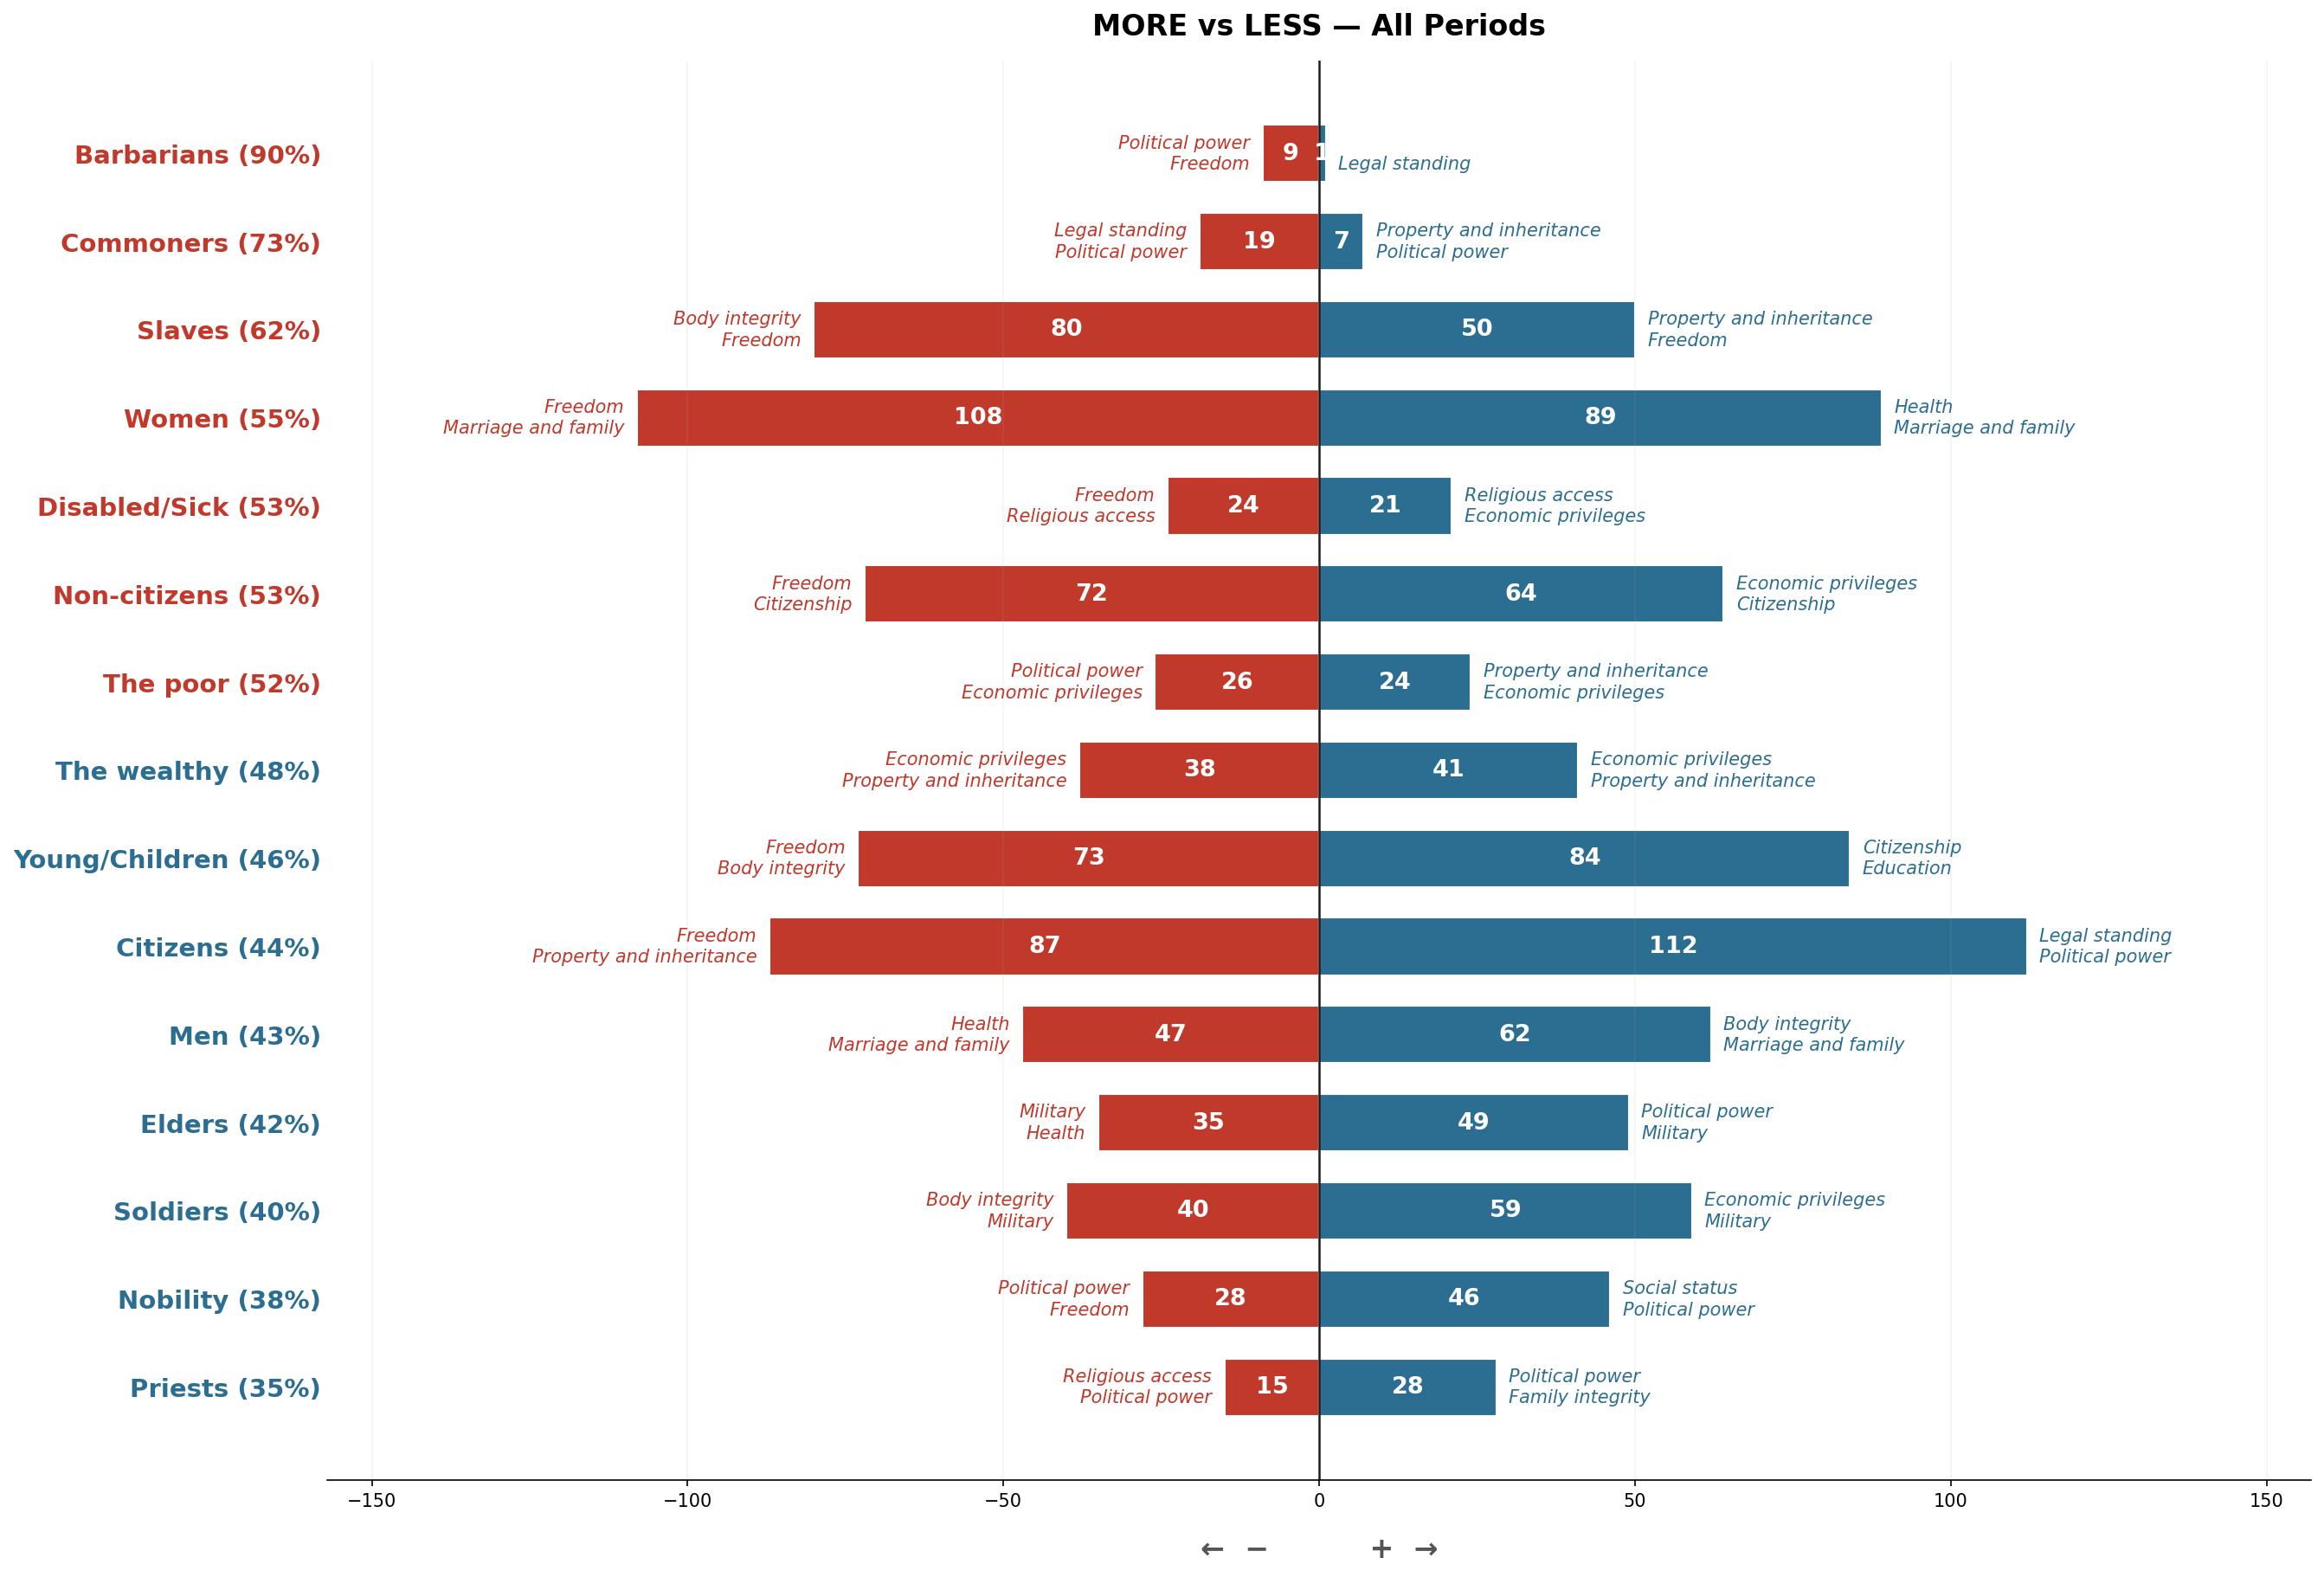

In [3]:
plot_diverging(dedup, title="MORE vs LESS \u2014 All Periods", min_total=10)

## MORE vs LESS — Per Period

Lower `min_total=5` per period because individual periods have fewer rules than the combined corpus.

### Archaic (750–480 BCE)

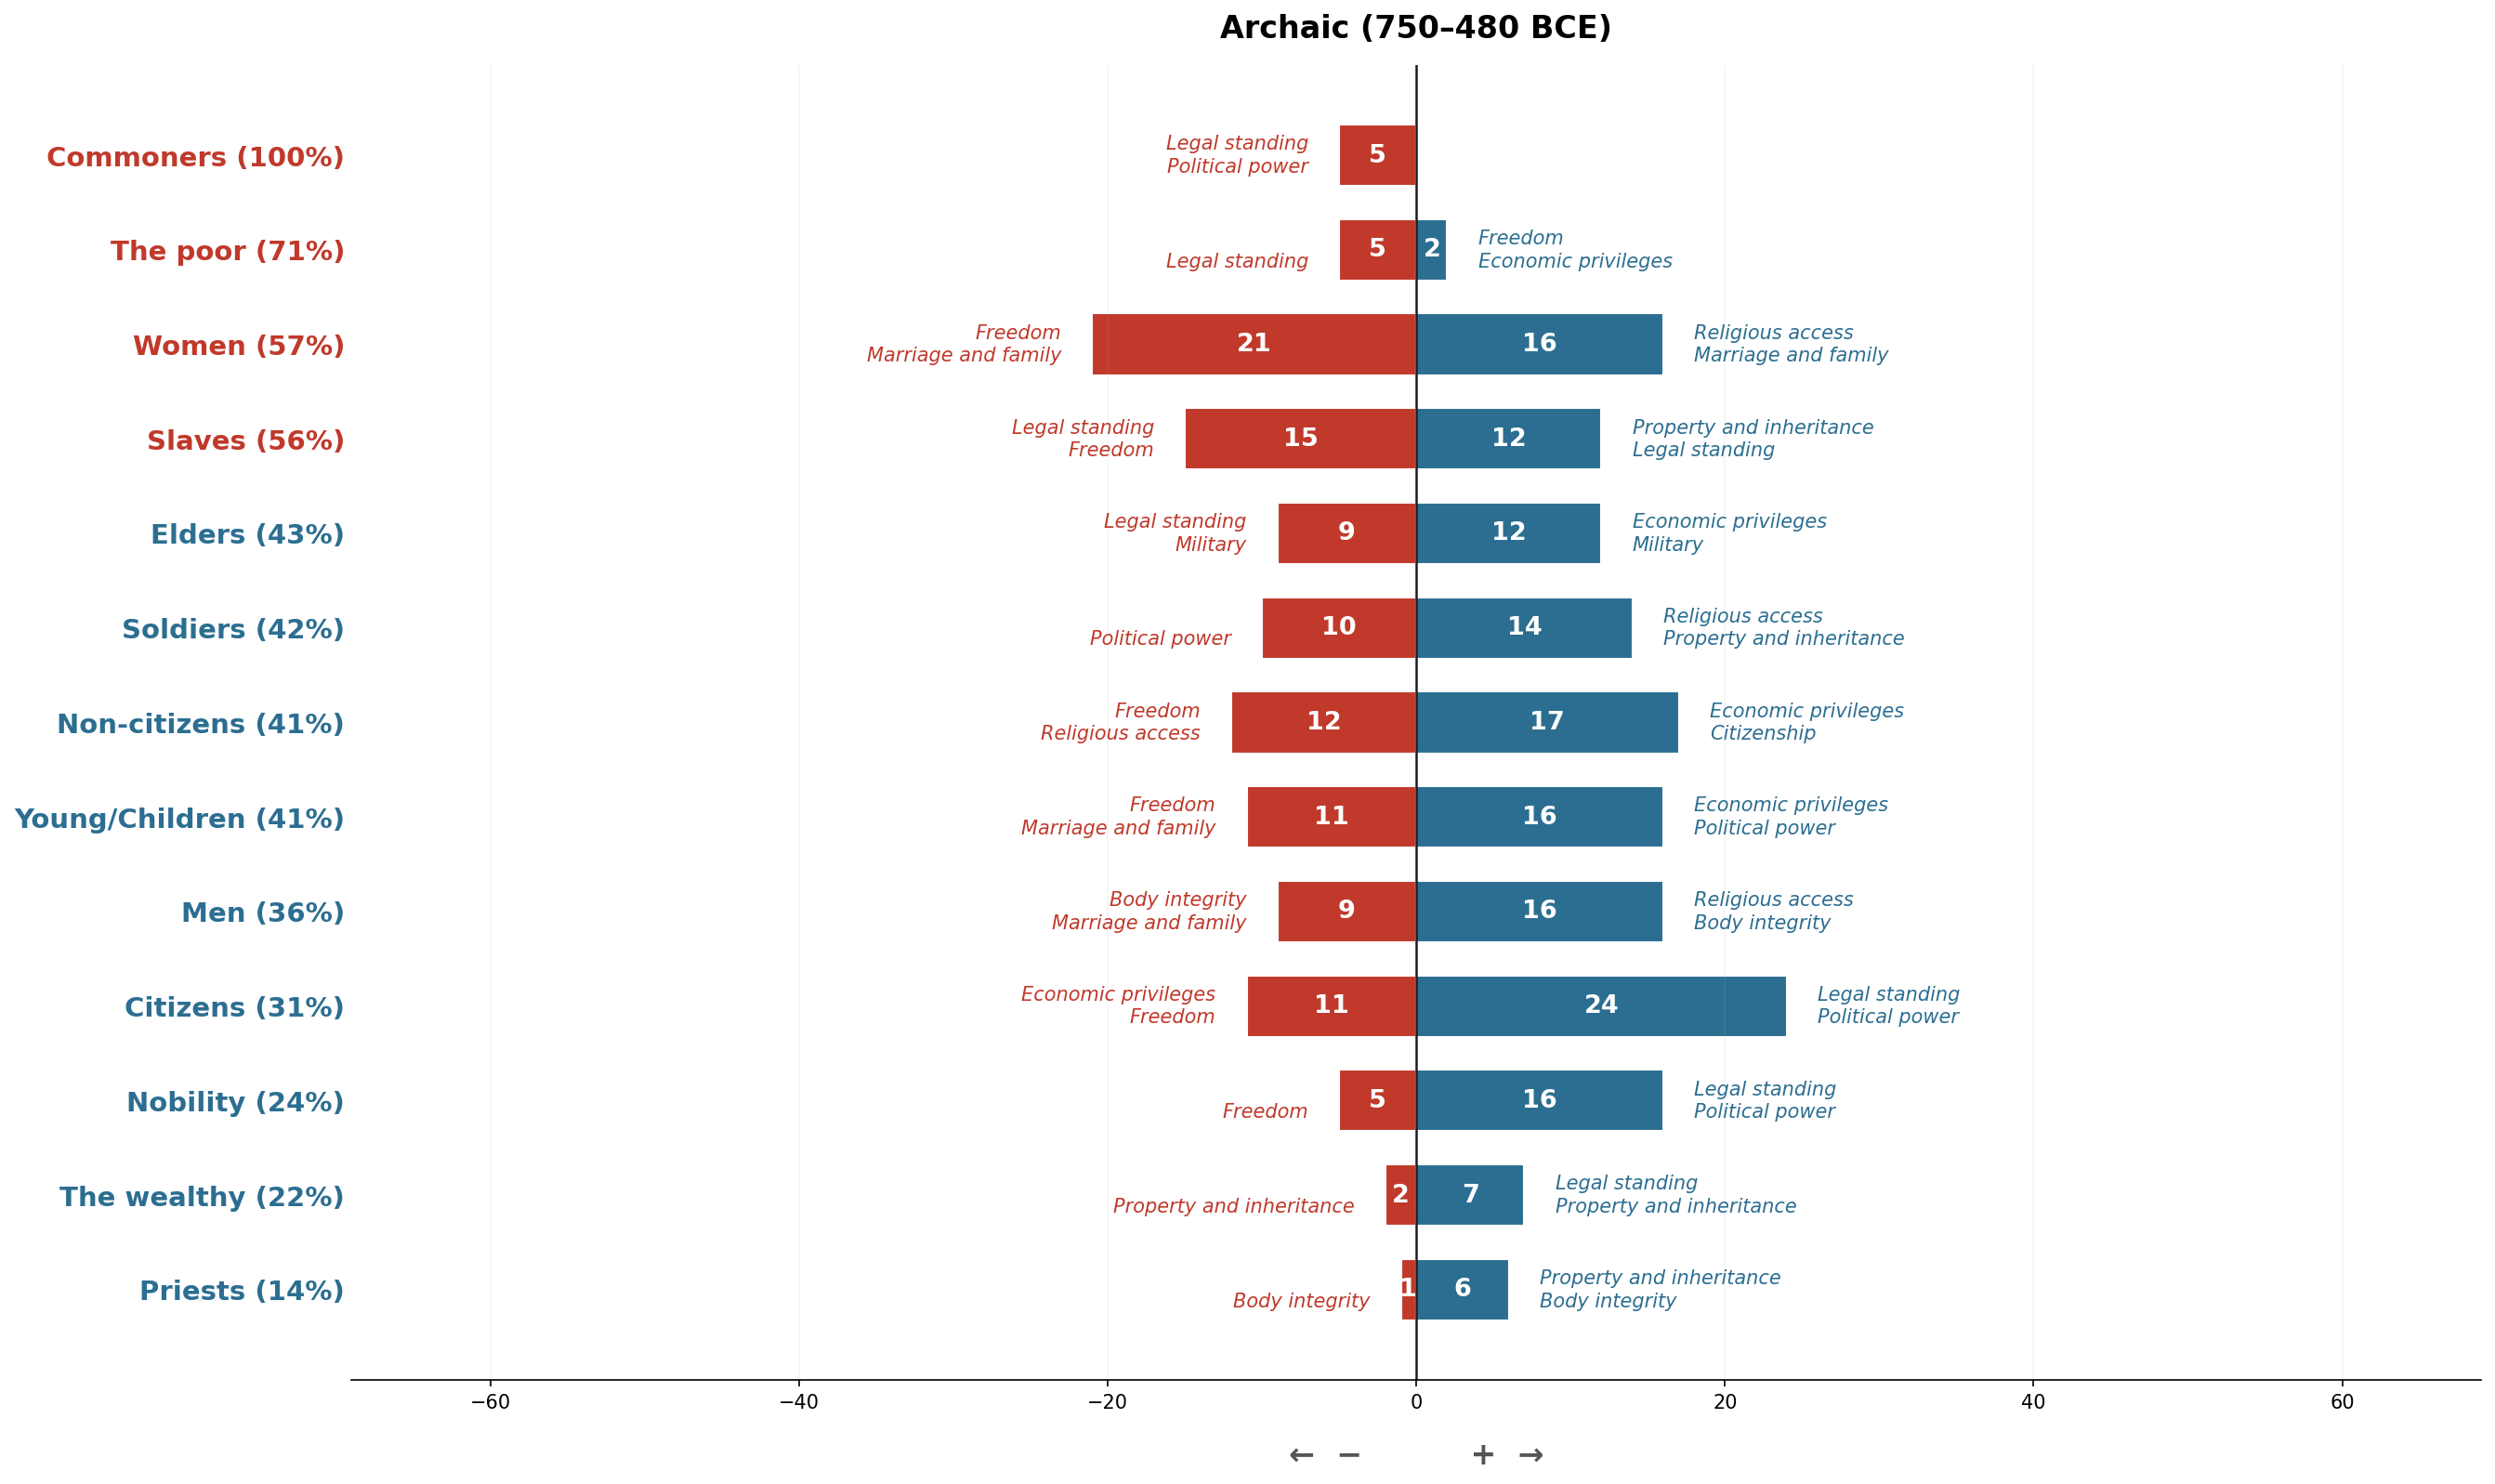

In [4]:
plot_diverging(dedup[dedup["period"] == "Archaic"], title="Archaic (750\u2013480 BCE)", min_total=5)

### Classical Athens (465–360 BCE)

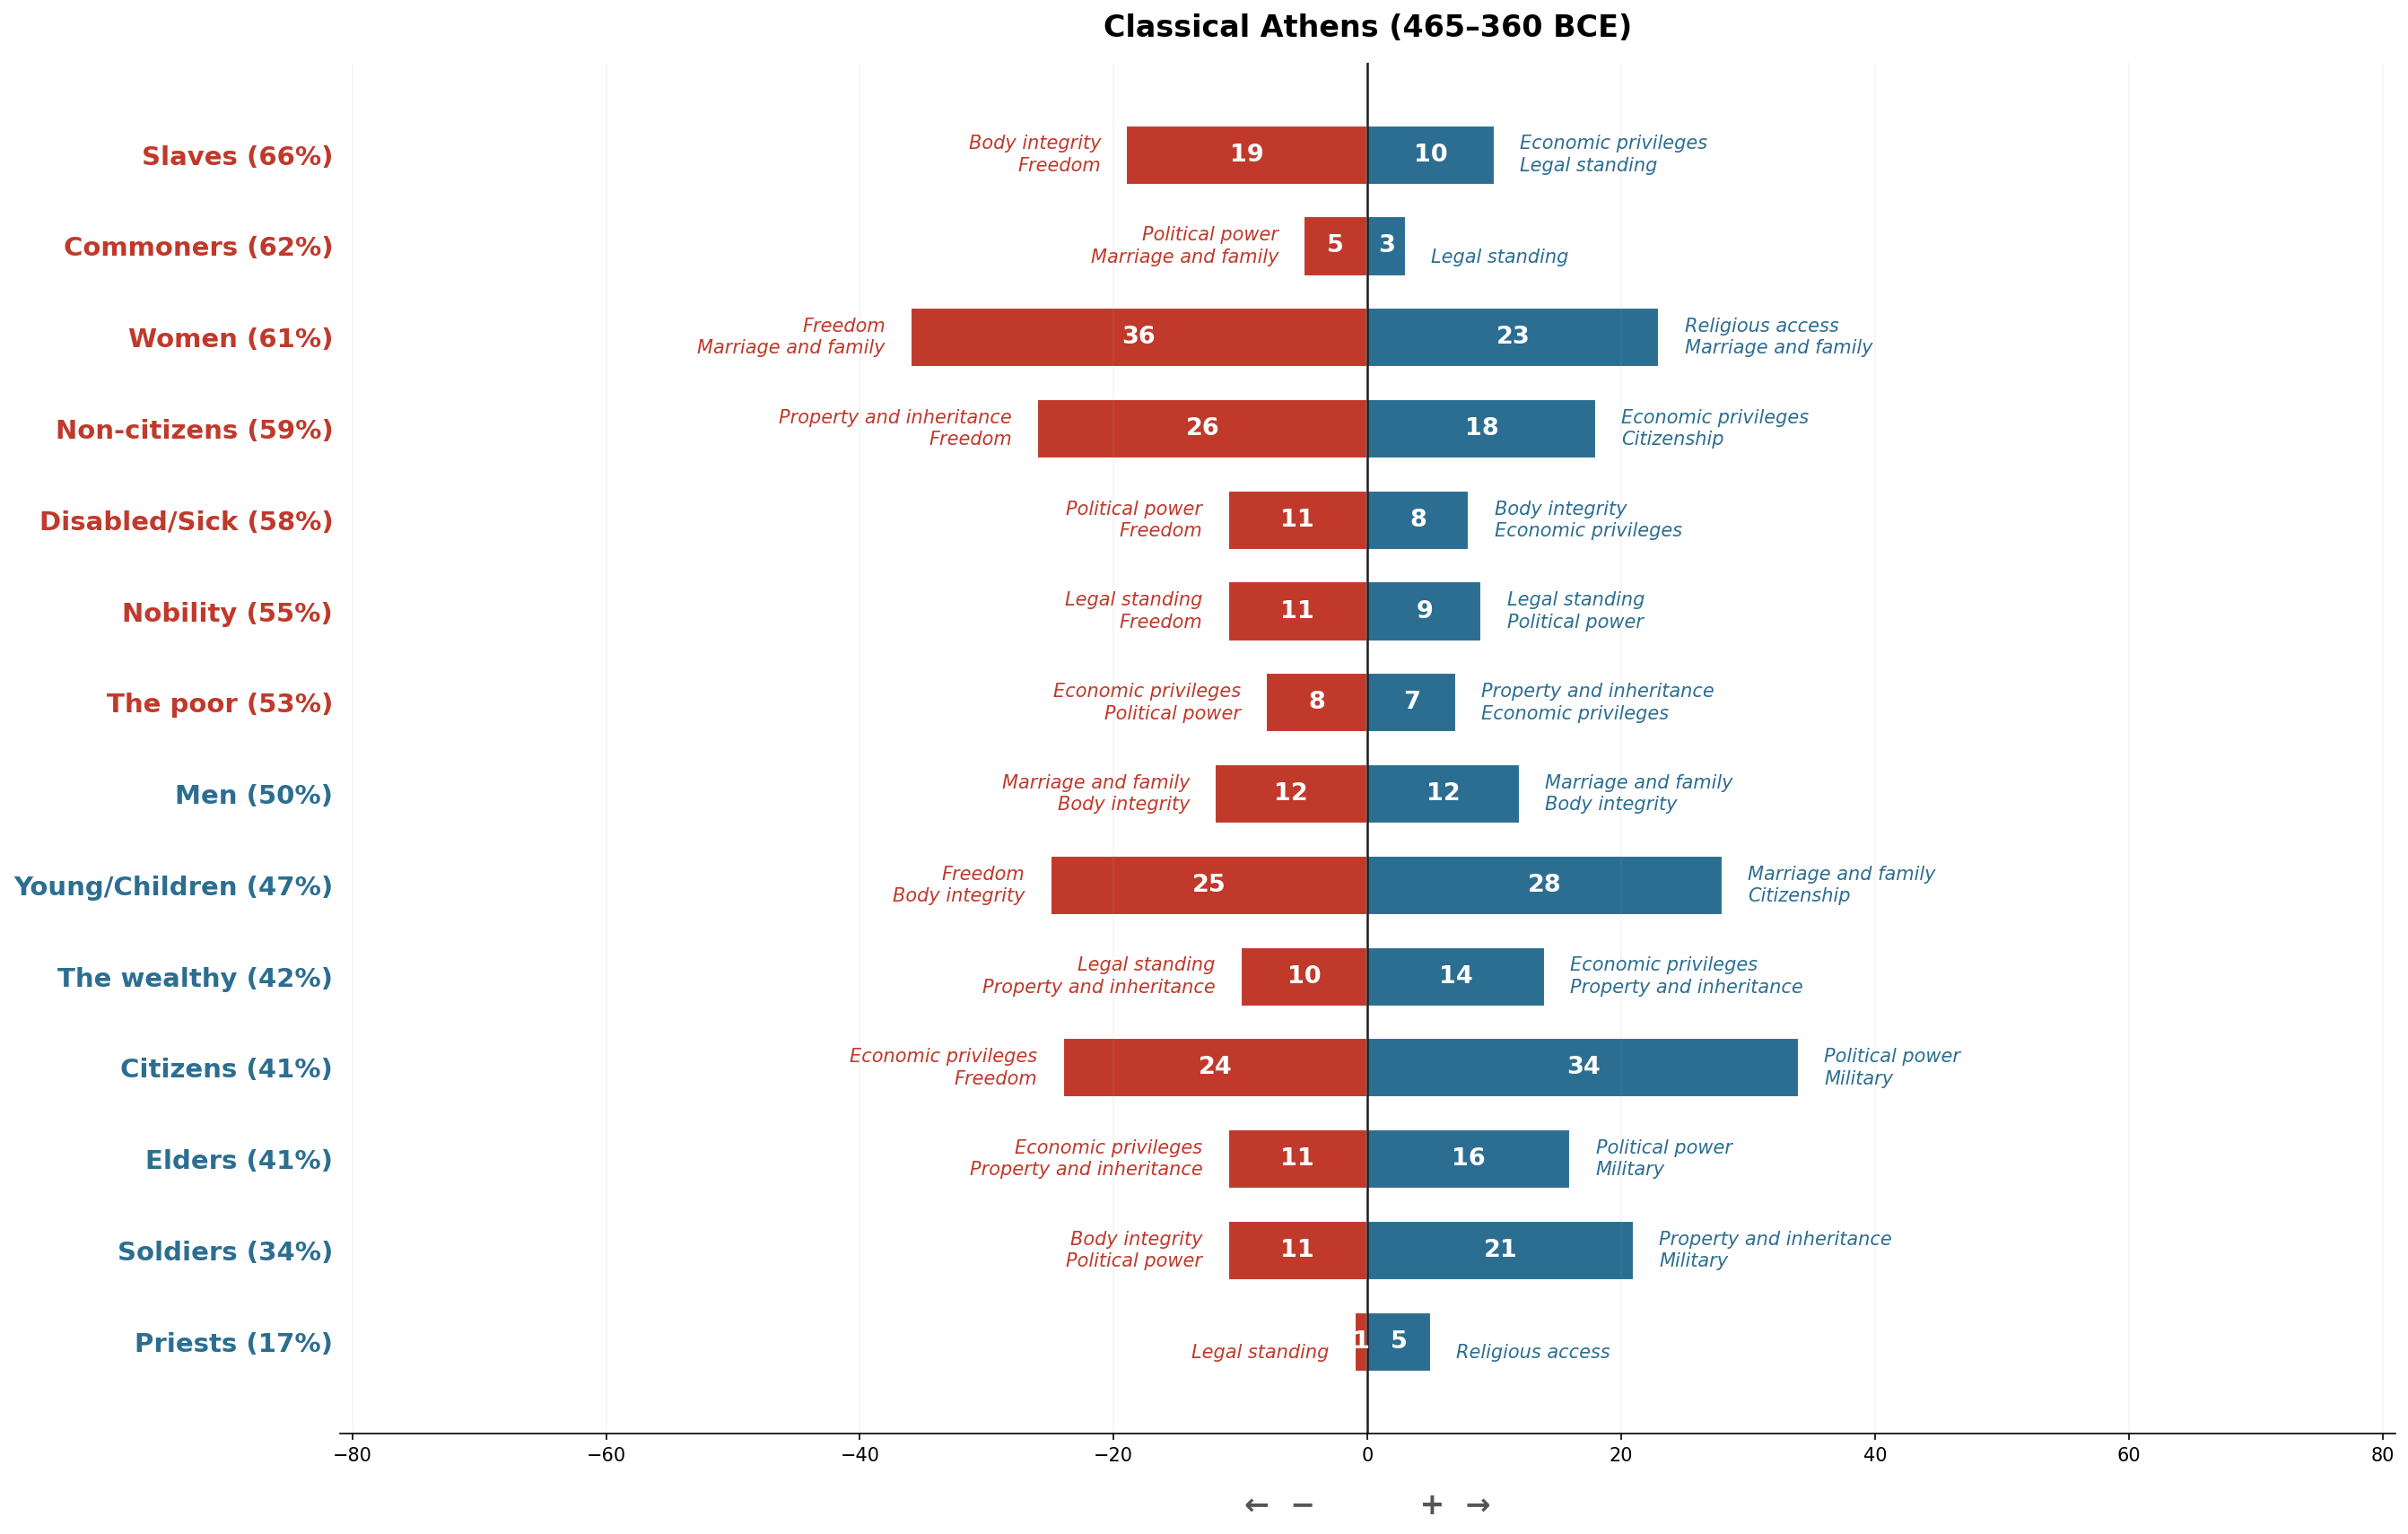

In [5]:
plot_diverging(dedup[dedup["period"] == "Classical Athens"], title="Classical Athens (465\u2013360 BCE)", min_total=5)

### Late Classical (354–165 BCE)

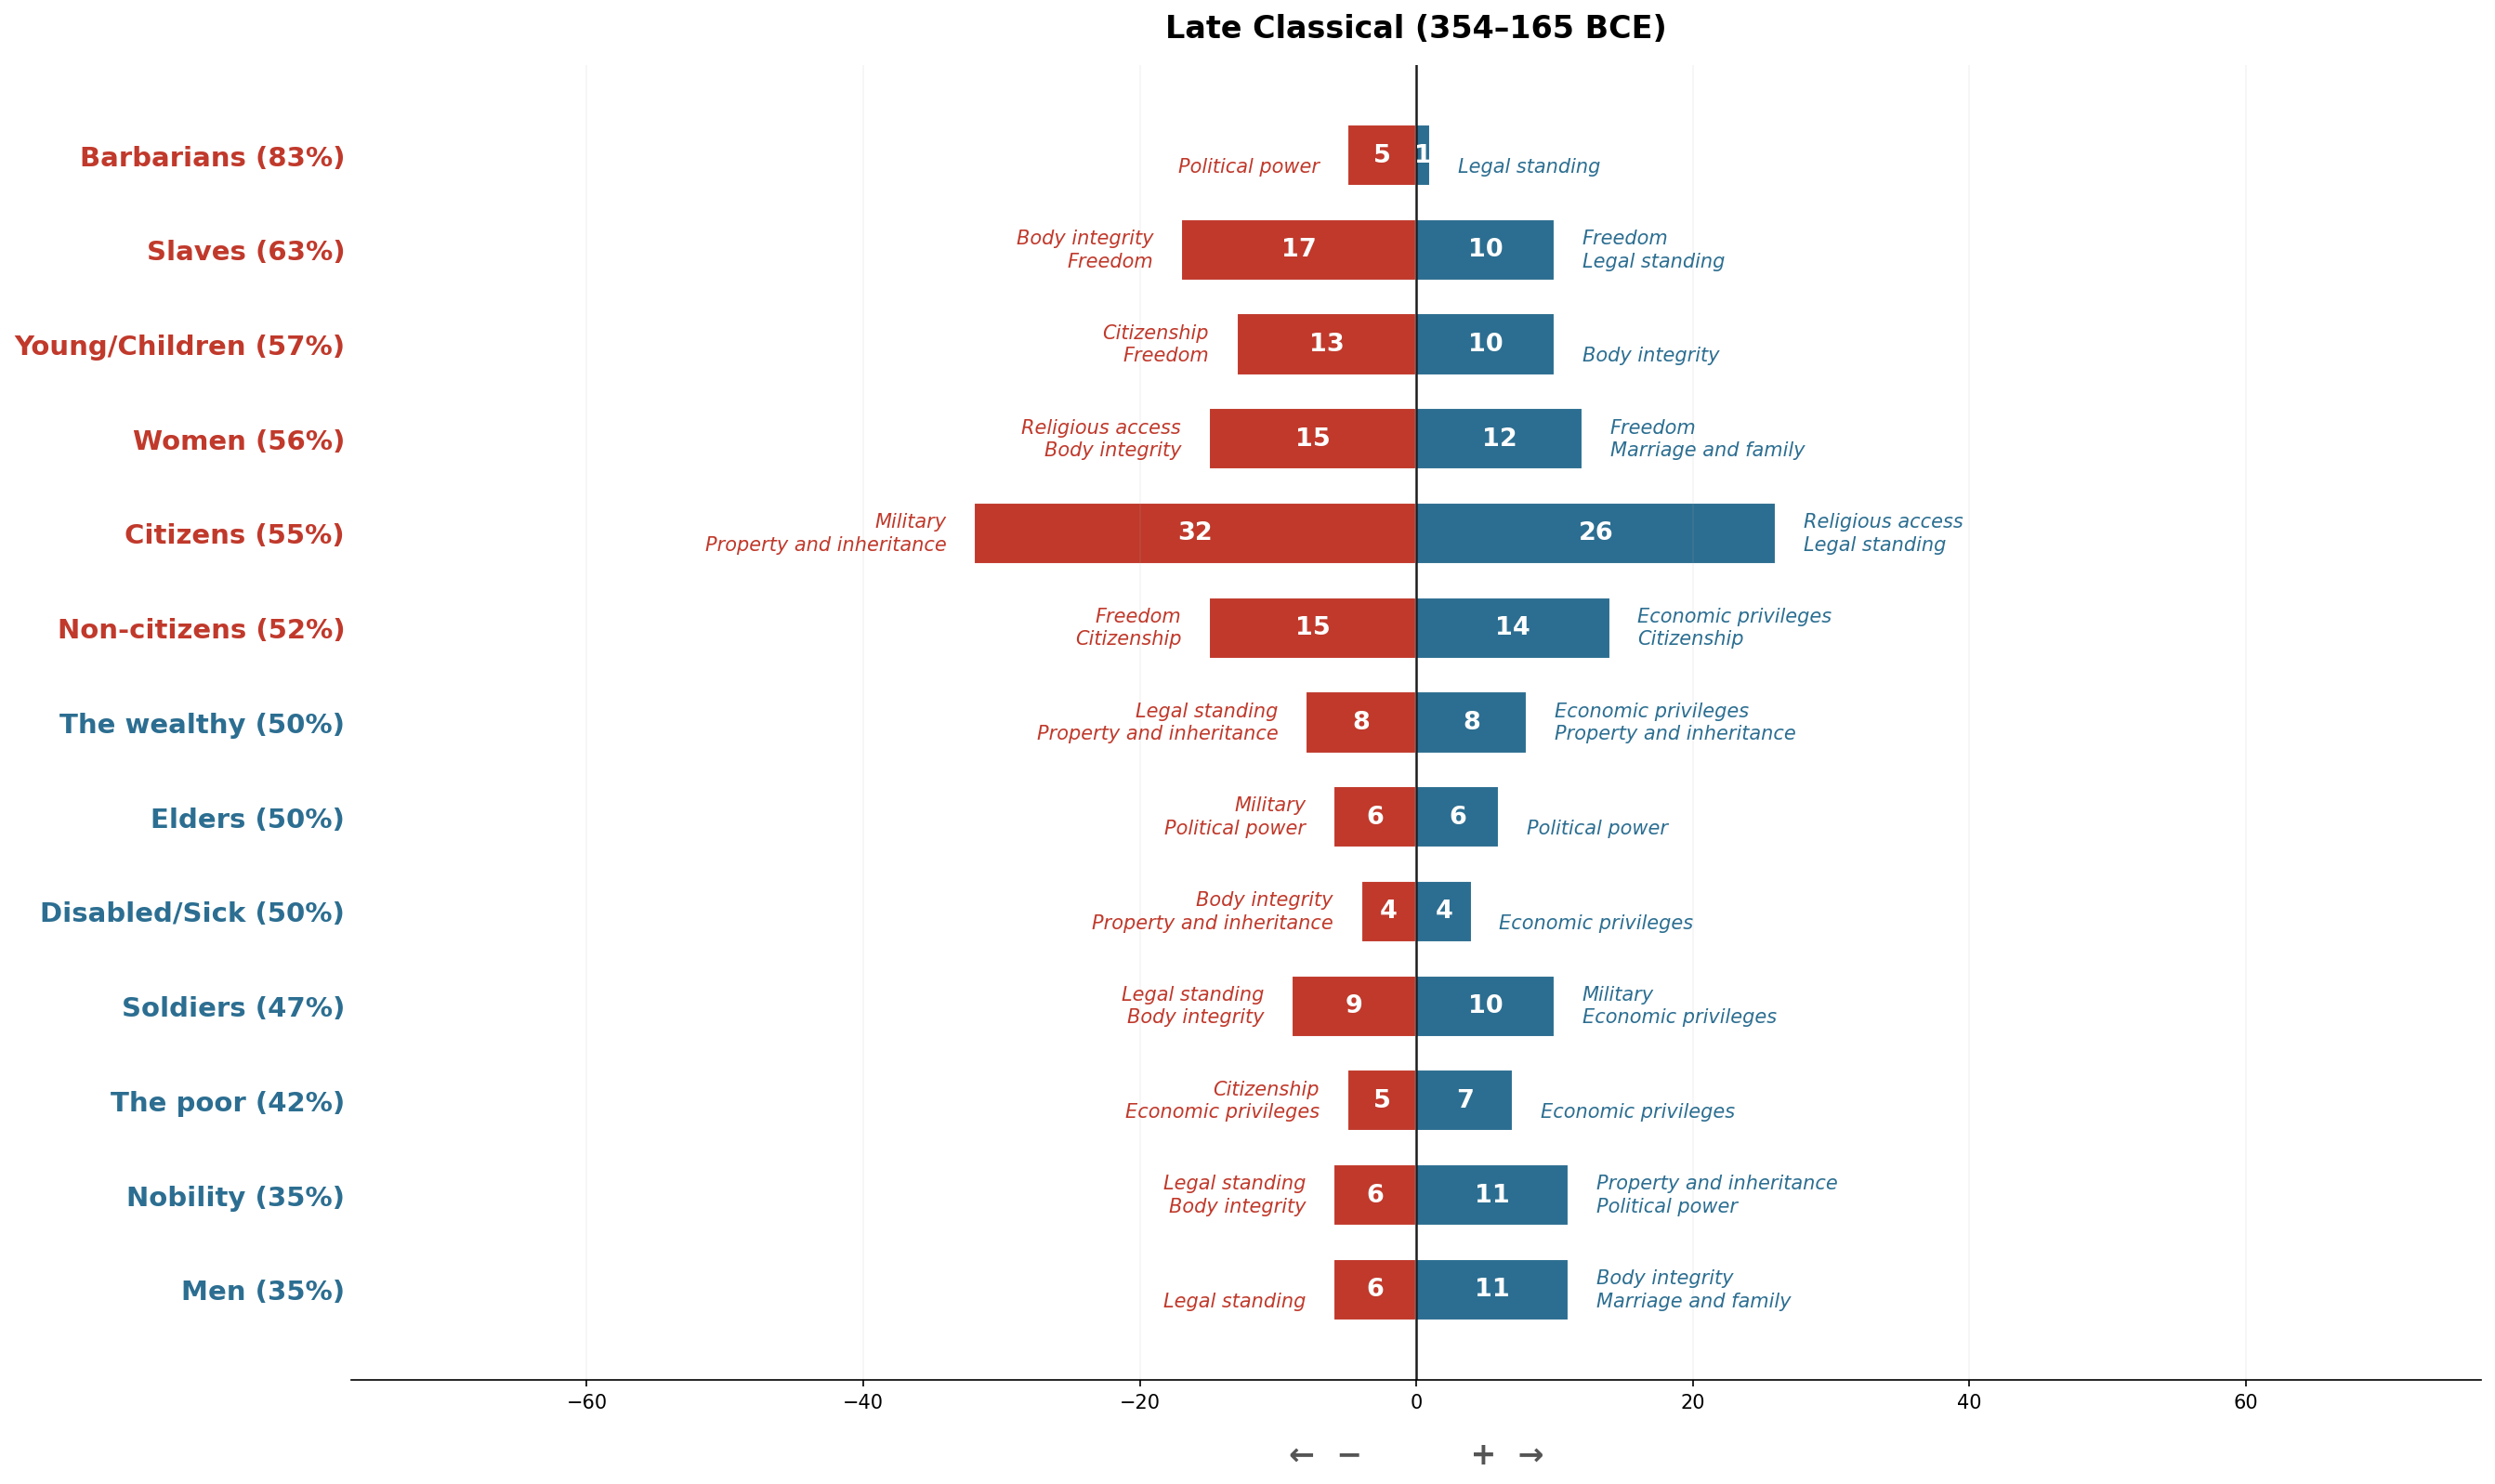

In [6]:
plot_diverging(dedup[dedup["period"] == "Late Classical"], title="Late Classical (354\u2013165 BCE)", min_total=5)

### Hellenistic (165 BCE – 105 CE)

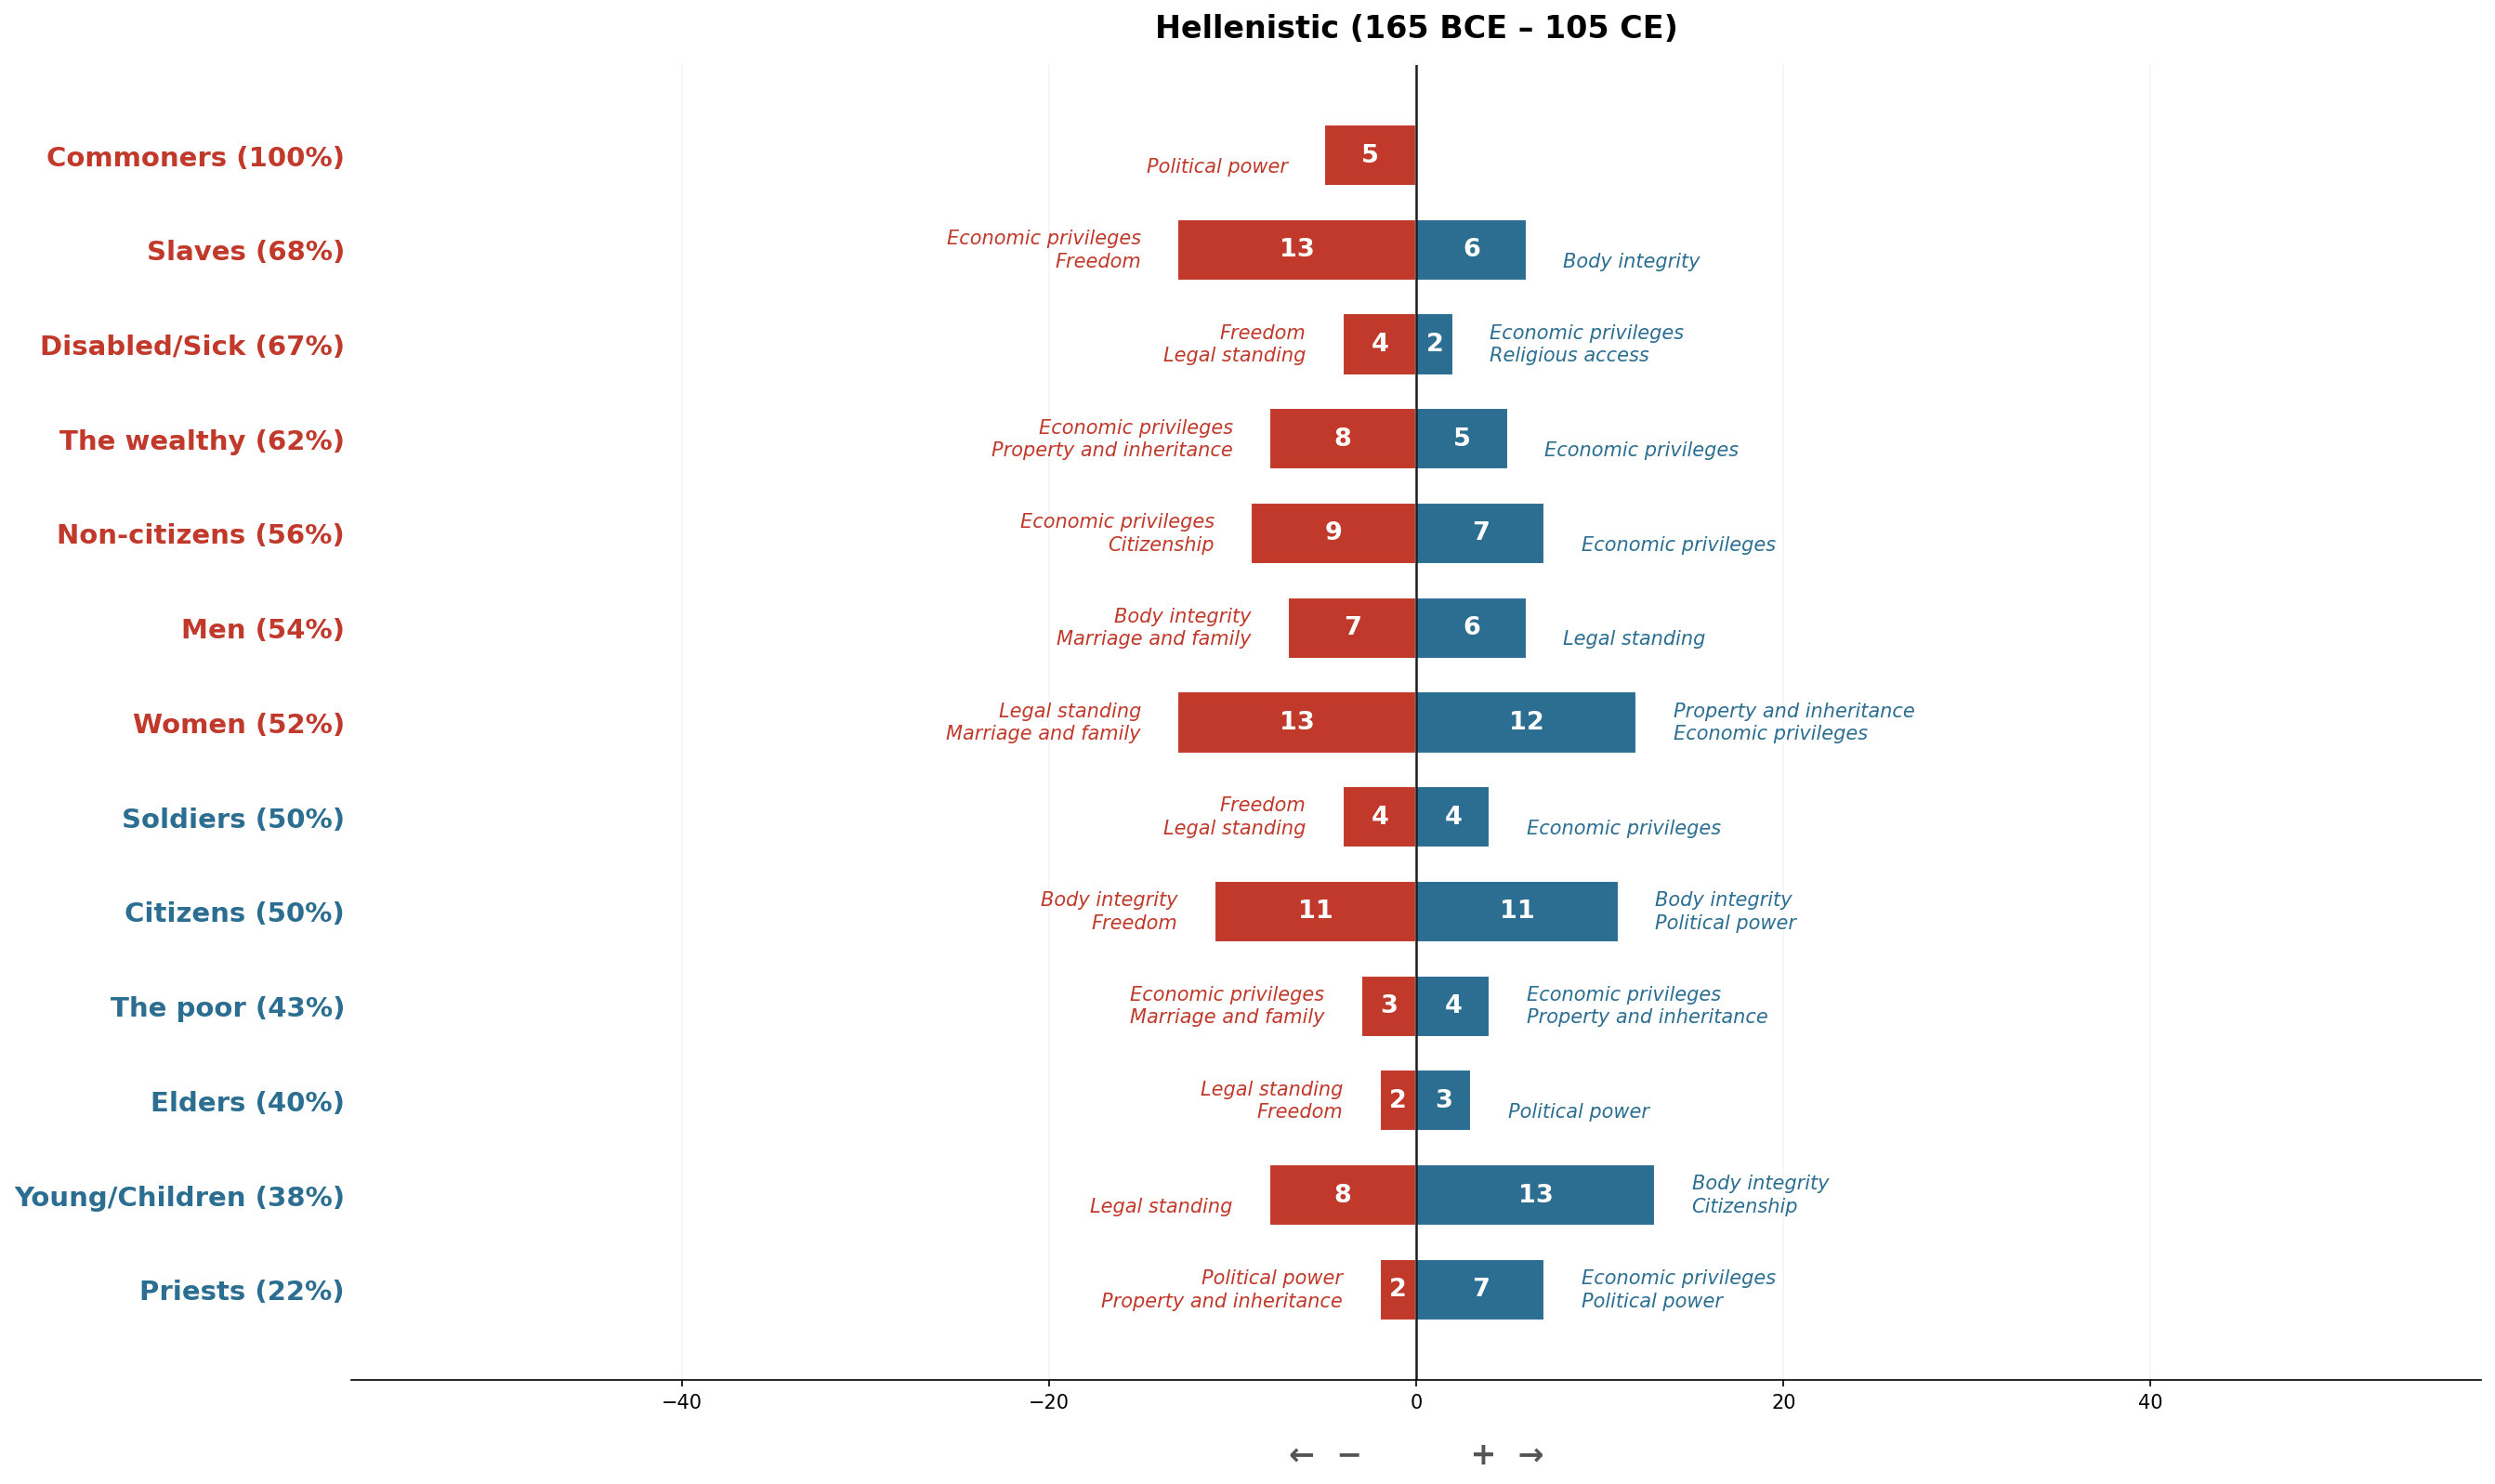

In [7]:
plot_diverging(dedup[dedup["period"] == "Hellenistic"], title="Hellenistic (165 BCE \u2013 105 CE)", min_total=5)

### High Roman Empire (135–205 CE)

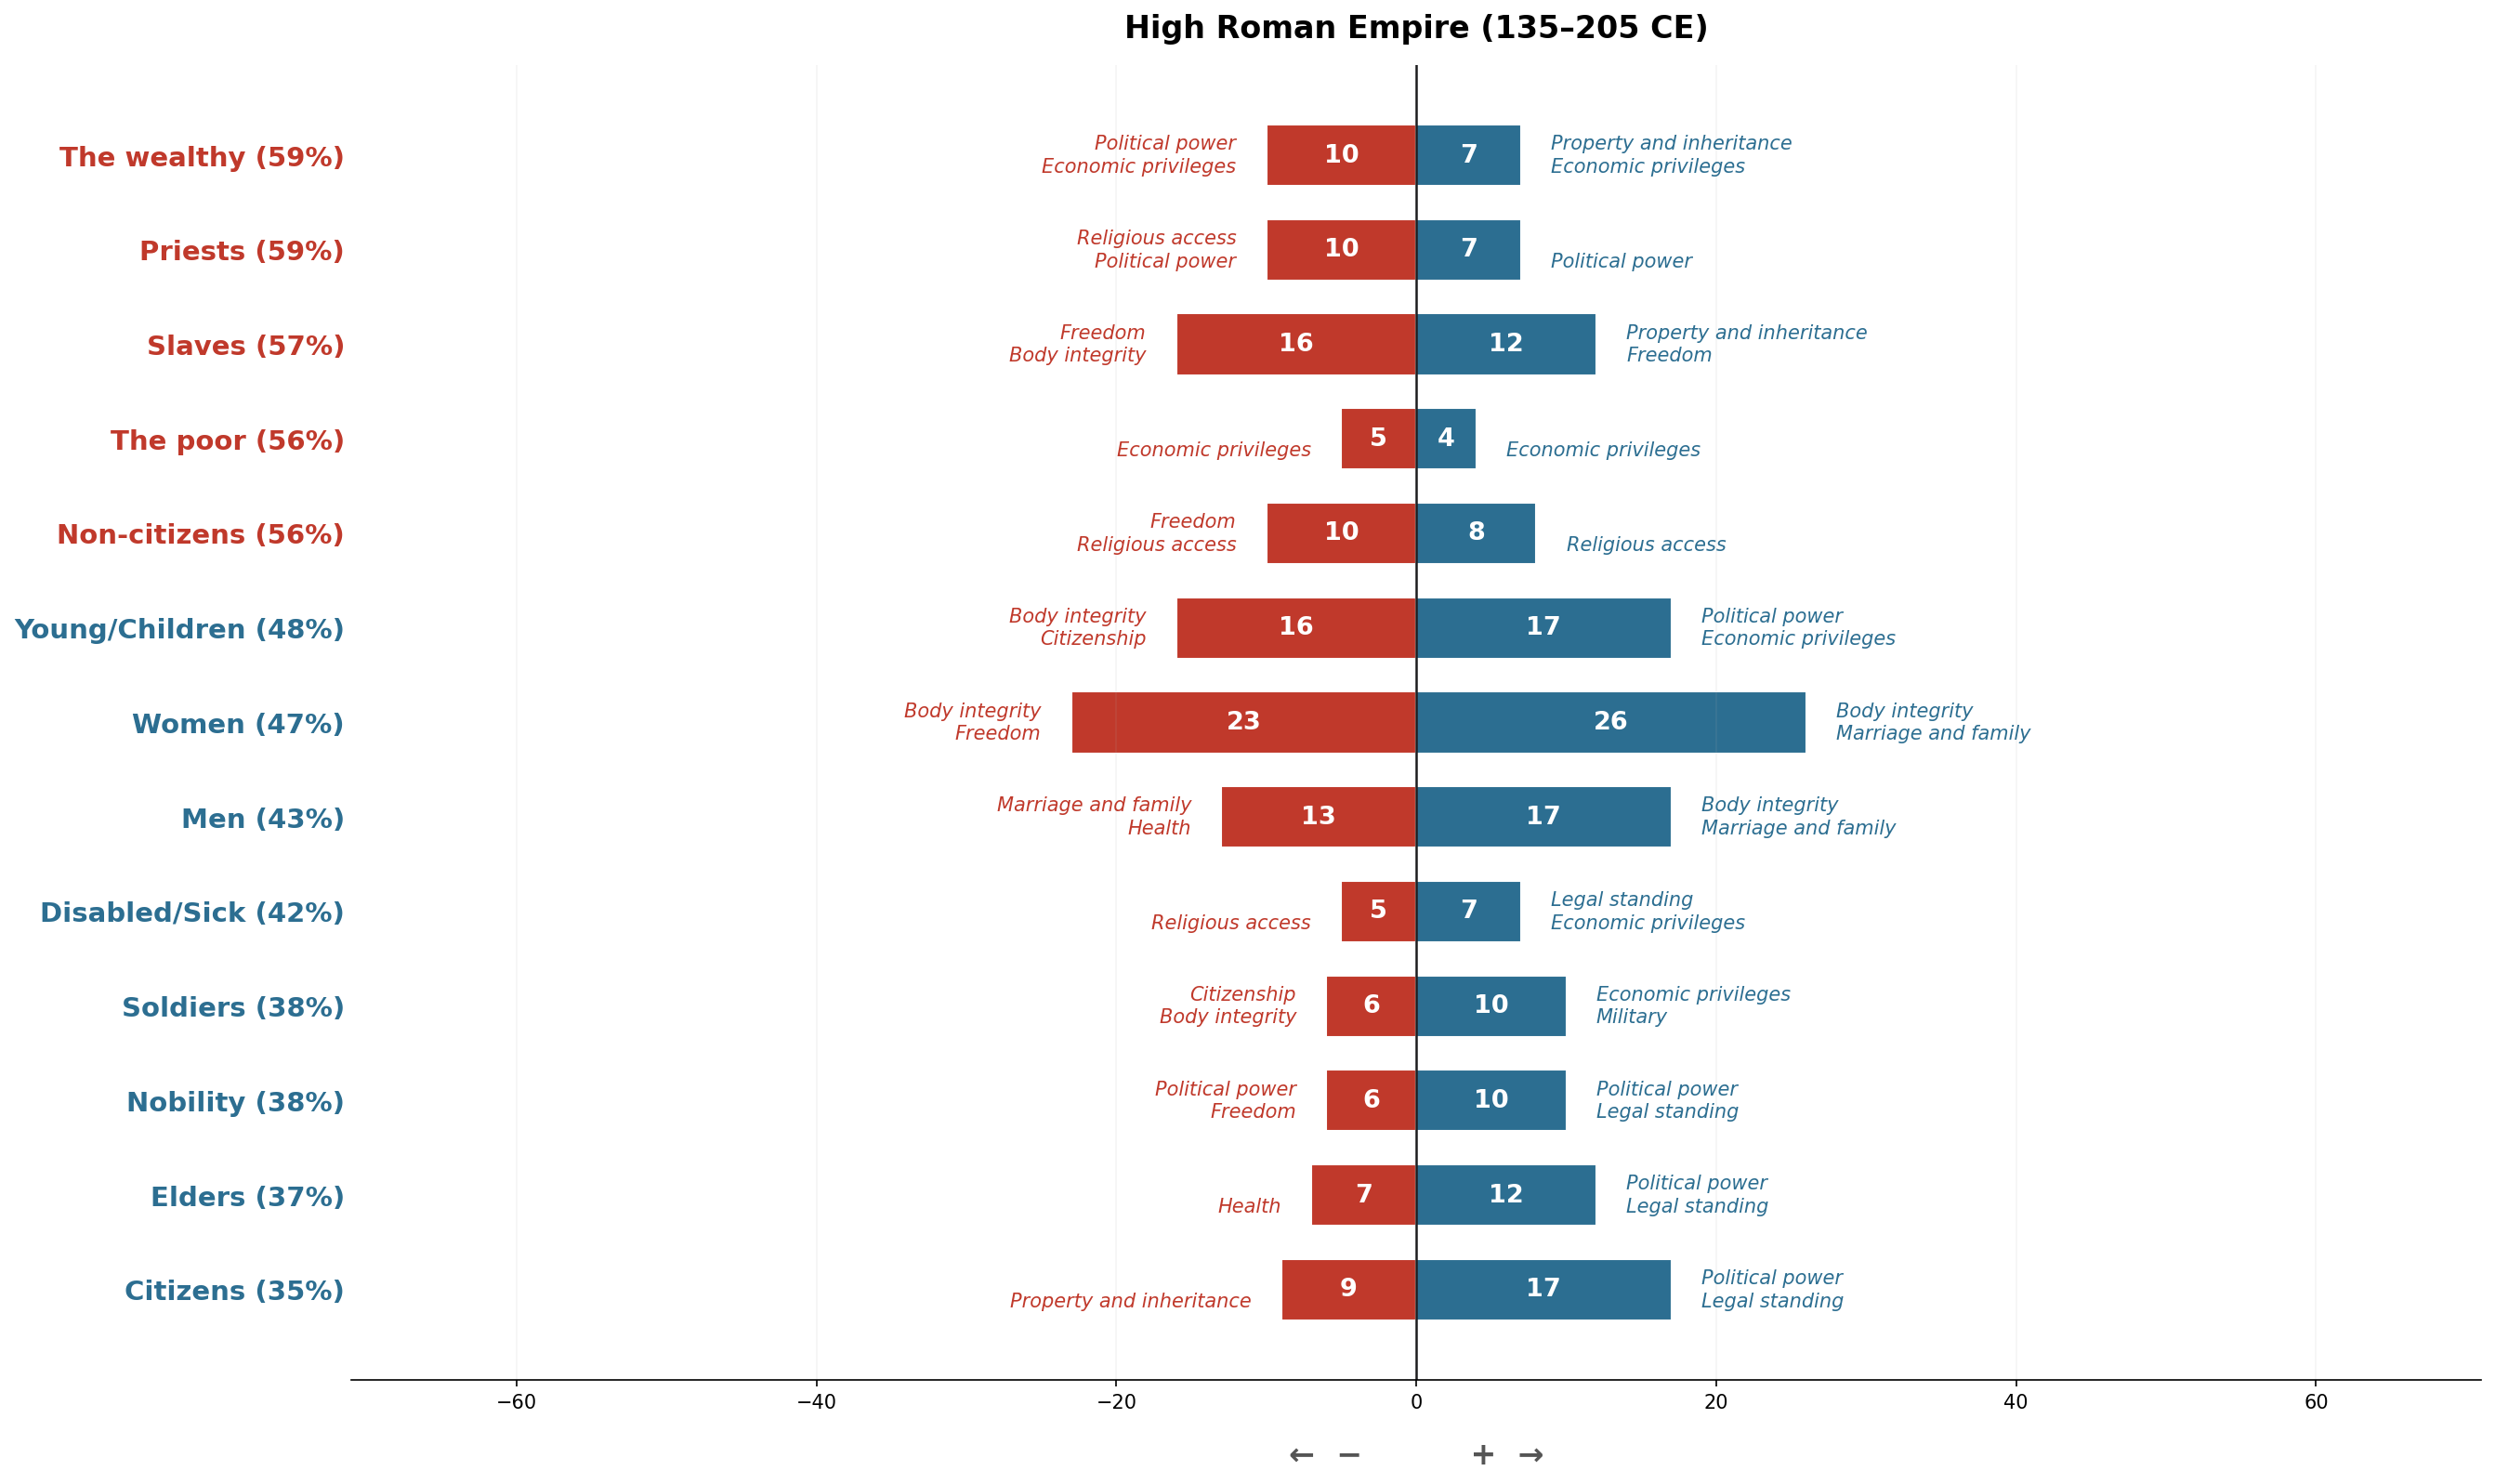

In [8]:
plot_diverging(dedup[dedup["period"] == "High Roman"], title="High Roman Empire (135\u2013205 CE)", min_total=5)